In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth_noise_2'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.78642556,  0.88036132,  0.20891062,  0.35224675,  0.87394593],
        [ 0.75441908,  0.8213523 ,  0.60443374, -0.06198505,  0.57319416],
        [ 0.68828022,  0.25202616,  0.18002453,  0.28766884,  1.1988493 ],
        ...,
        [ 0.77161463,  0.31267781,  0.71742885,  0.08159254,  0.82330127],
        [ 0.75992797,  0.28187078,  0.70339302,  0.10117528,  0.85130535],
        [ 0.79333971,  0.31459264,  0.77120609,  0.00907313,  0.81699051]],
       shape=(100000, 5))]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 18.03341818,         -inf,         -inf, ..., 589.58379569,
        565.05962766, 523.91587939], shape=(100000,))]

In [7]:
sampler.now_covariances

[array([[ 7.09552454e-05,  6.93778878e-05,  1.44247267e-04,
         -1.95913893e-04, -7.28438391e-05],
        [ 6.93778878e-05,  1.38464987e-04,  1.04595539e-04,
         -1.44607413e-04, -1.30317072e-04],
        [ 1.44247267e-04,  1.04595539e-04,  3.12082166e-04,
         -4.22536148e-04, -1.17573374e-04],
        [-1.95913893e-04, -1.44607413e-04, -4.22536148e-04,
          5.72185087e-04,  1.61825141e-04],
        [-7.28438391e-05, -1.30317072e-04, -1.17573374e-04,
          1.61825141e-04,  1.24270139e-04]])]

In [8]:
np.argmax(logden_list)

np.int64(97926)

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.21862382, 0.95041872, 0.80204114, 8.20395231, 0.44974514]])

In [10]:
log_density(maxld_pt1)

array([5.99390138])

In [11]:
log_density([param_true])

array([8.61286619])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[np.float64(6.0), np.float64(1.0), 0.7, 9, 0.4]

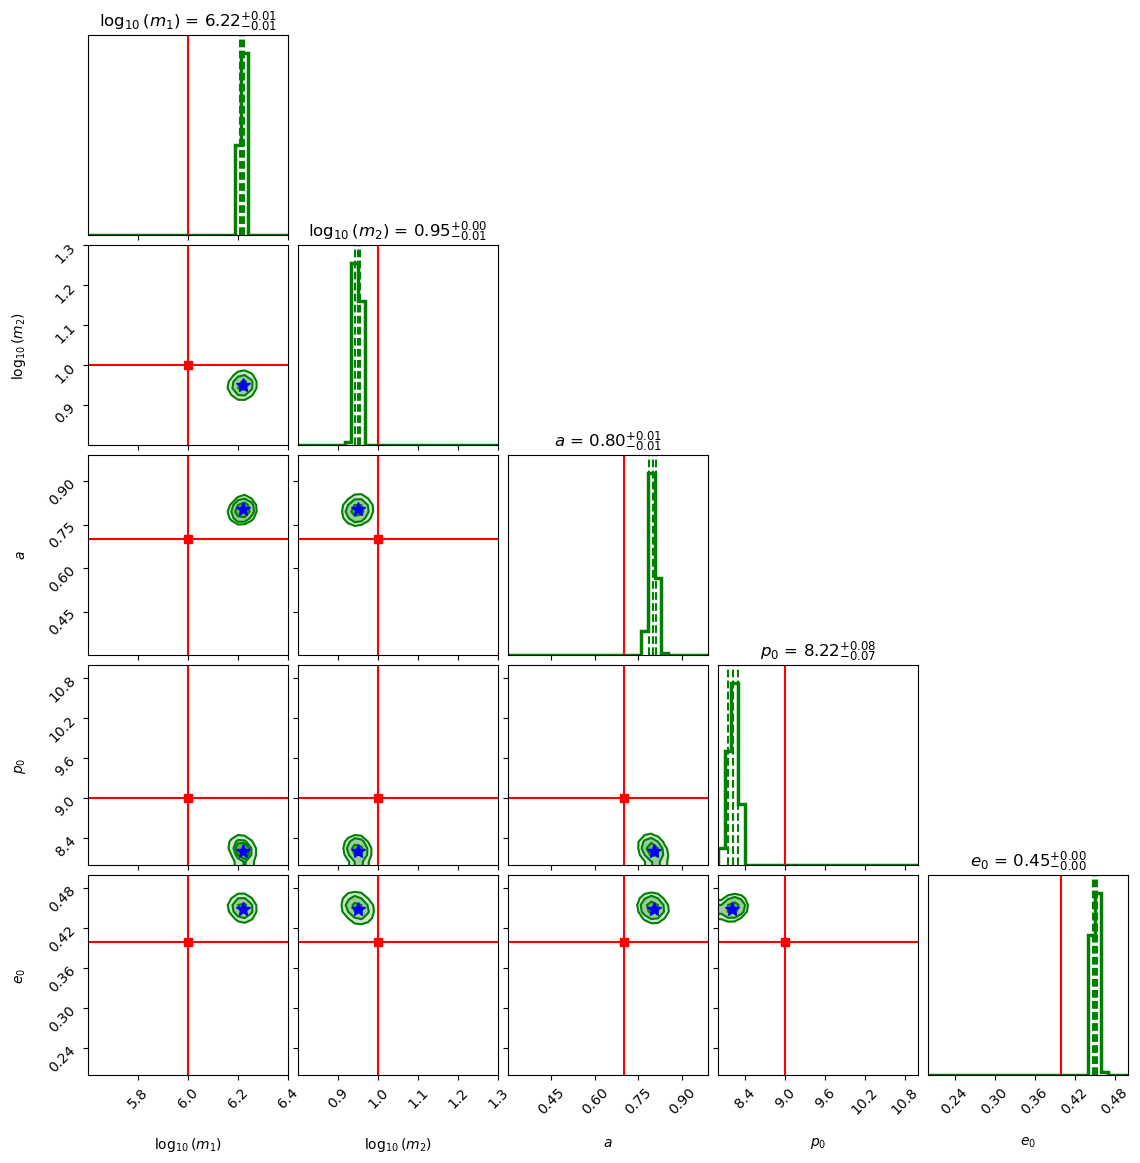

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 180.1  (0.18% of N=100000)


# connection plot

In [15]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.21862382, 0.95041872, 0.80204114, 8.20395231, 0.44974514]])

In [16]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [17]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [18]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [19]:
logden_theory_proc1

array([5.99390138, 3.15247924, 4.23120847, 3.30884689, 4.56398532,
       3.87914504, 3.53254757, 3.72294989, 4.15937644, 3.33561035,
       3.39252462, 3.94899783, 3.58014991, 4.48709004, 3.41759435,
       2.68062915, 3.83899479, 3.93700404, 4.09099675, 2.99226982,
       4.42730025, 3.03300406, 3.1146375 , 3.01130826, 2.95093554,
       3.70389415, 3.00056333, 3.18949849, 3.42256502, 3.35082193,
       3.60905031, 4.07040191, 2.80935212, 3.70155401, 3.50757424,
       4.23471847, 3.80410106, 2.77372912, 4.03330791, 4.20197952,
       2.74322985, 4.82077779, 3.78788767, 2.30893639, 2.96555638,
       3.18797428, 2.9285832 , 2.98987744, 2.68520044, 8.61286619])

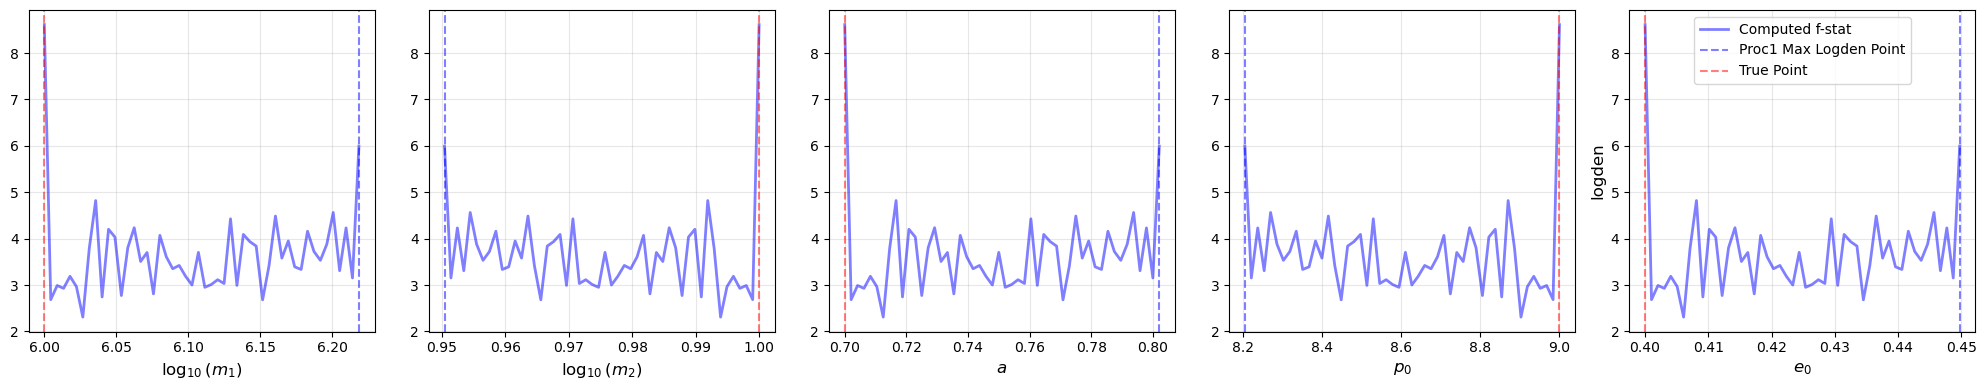

In [20]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
